# Distribution of distinct CCF clusters (subclones) per hotspot event (Figure 5C)


In [99]:
# Load libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Define parameters
CLONAL_CCF_THRESHOLD = 0.90     # CCF >= this -> counted as clonal
SUBCLONAL_CCF_THRESHOLD = 0.90  # CCF < this -> counted as subclonal
MIN_SVS_PER_SAMPLE = 3          # minimum non-NaN CCF SVs required to keep a sample/event

HOTSPOT_ORDER = ["TP53", "MYC", "CCND3", "CCNE1", "CDK4-MDM2"]
DEFAULT_LABEL = "cSV"  # label for clustered SVs that don't overlap any defined hotspot

# Samples excluded because of unreliable read length / CCF estimation
SAMPLES_TO_EXCLUDE = ["SJOS030101_D2", "SJOS040149_R1"]

## Helper Functions

In [ ]:
# Chromosome / ID helpers
def standardize_chrom(series):
    """Strip a leading 'chr' prefix and cast to string for safe comparison."""
    return series.astype(str).str.replace("^chr", "", regex=True)


def extract_tumor_id(sample_name):
    """Extract a canonical tumour ID from a paired sample name."""
    sample_name = str(sample_name)
    if "TARGET" in sample_name:
        return "-".join(sample_name.split("-")[:4])
    return sample_name.split("-")[0]

# Per-sample variant processing
def process_variants(structure_df, certainty_df, variant_type, sample, purity):
    """Annotate a cluster-certainty table with CCF and clonality status.
    """
    structure_df = structure_df.copy()
    structure_df["CCF"] = structure_df["proportion"] / purity
    structure_df["Clonality_Status"] = np.where(
        structure_df["CCF"] >= CLONAL_CCF_THRESHOLD, "Early_Clonal", "Subclonal"
    )

    merged_df = certainty_df.merge(
        structure_df[["cluster", "CCF", "Clonality_Status"]],
        left_on="most_likely_assignment",
        right_on="cluster",
        how="left",
    )
    merged_df["Variant_Type"] = variant_type
    merged_df["Sample_ID"] = sample
    return merged_df.drop(columns=["cluster"])


def load_sample_variants(sample_dir, sample, purity):
    """Load and process SV and SNV tables for one sample.
    Uses the post_assign directory when available, otherwise ccube_out.
    Returns an empty list if any required file is missing.
    """
    sample_dir = Path(sample_dir)
    post_assign_dir = sample_dir / "ccube_out" / "post_assign"
    ccube_out_dir = sample_dir / "ccube_out"

    sv_dir = post_assign_dir if post_assign_dir.exists() else ccube_out_dir
    snv_dir = sv_dir / "snvs"

    try:
        sv_structure = pd.read_csv(sv_dir / f"{sample}_subclonal_structure.txt", sep="\t")
        sv_certainty = pd.read_csv(sv_dir / f"{sample}_cluster_certainty.txt", sep="\t")
        snv_structure = pd.read_csv(snv_dir / f"{sample}_subclonal_structure.txt", sep="\t")
        snv_certainty = pd.read_csv(snv_dir / f"{sample}_cluster_certainty.txt", sep="\t")
    except FileNotFoundError as err:
        print(f"  - Missing file for {sample}: {err}")
        return []

    return [
        process_variants(sv_structure, sv_certainty, "SV", sample, purity),
        process_variants(snv_structure, snv_certainty, "SNV", sample, purity),
    ]


def load_terra_targets(terra_table_path):
    """Load the Terra table and resolve which samples have clustering targets."""
    terra_table = pd.read_csv(terra_table_path, sep="\t")

    if "postassign_cluster_results" in terra_table.columns:
        terra_table["target_tar"] = terra_table["postassign_cluster_results"].fillna(
            terra_table["svclone_final_tar"]
        )
    else:
        terra_table["target_tar"] = terra_table["svclone_final_tar"]

    df_terralinks = (
        terra_table[terra_table["target_tar"].notna()]
        .rename(columns={"entity:SV_Clone_Samples_id": "Samples"})
        .copy()
    )
    print(f"Samples with clustering targets: {df_terralinks.shape[0]}")
    return df_terralinks


def build_master_variant_table(df_terralinks, base_dir):
    """Loop over every sample in df_terralinks and build the master SV/SNV table."""
    base_dir = Path(base_dir)
    master_frames = []
    for _, row in df_terralinks.iterrows():
        sample = row["Samples"]
        print(f"Processing {sample}...")
        master_frames.extend(
            load_sample_variants(base_dir / sample, sample, row["purity"])
        )
    final_master_df = pd.concat(master_frames, ignore_index=True)
    print("Master dataframe created successfully.")
    return final_master_df

# Hotspot annotation / matching
def annotate_clustered_svs_with_hotspots(clustered_svs, hotspots, default_label=DEFAULT_LABEL):
    """Label every clustered SV (cSV) event with the hotspot it overlaps.
    Every row is returned, Rows that don't overlap any hotspot get
    `default_label`. Matching regions are extended to the UNION of the cSV span and the
    hotspot span. Extending guarantees the hotspot's full defined span is always covered.
    """
    svs = clustered_svs.copy()
    svs["hotspot_event"] = default_label
    sv_chrom = standardize_chrom(svs["chr"])

    for _, hotspot in hotspots.iterrows():
        h_chrom = str(hotspot["chrom"]).replace("chr", "")
        mask = (
            (sv_chrom == h_chrom)
            & (svs["start"] <= hotspot["end"])
            & (svs["end"] >= hotspot["start"])
            & (svs["hotspot_event"] == default_label)  # first match wins
        )
        if not mask.any():
            continue
        svs.loc[mask, "start"] = np.minimum(svs.loc[mask, "start"], hotspot["start"])
        svs.loc[mask, "end"] = np.maximum(svs.loc[mask, "end"], hotspot["end"])
        svs.loc[mask, "hotspot_event"] = hotspot["event"]

    return svs


def match_svs_to_regions(regions_df, variant_df):
    """Keep SVs with at least one breakend inside a sample-matched region.

    `regions_df` must have columns: Tumor_ID, chr, start, end, hotspot_event
    (optionally event_id). 
    `variant_df` must have Sample_ID, chr1, pos1, chr2, pos2.
    """
    matched = []

    for _, region in regions_df.iterrows():
        target_id = region["Tumor_ID"]
        r_chrom = str(region["chr"]).replace("chr", "")
        r_start, r_end = region["start"], region["end"]

        sample_svs = variant_df[variant_df["Sample_ID"] == target_id]
        if sample_svs.empty:
            continue

        mask = (
            (standardize_chrom(sample_svs["chr1"]) == r_chrom)
            & sample_svs["pos1"].between(r_start, r_end)
        ) | (
            (standardize_chrom(sample_svs["chr2"]) == r_chrom)
            & sample_svs["pos2"].between(r_start, r_end)
        )

        hits = sample_svs.loc[mask].copy()
        if hits.empty:
            continue

        hits["hotspot_event"] = region["hotspot_event"]
        hits["event_id"] = region.get("event_id", "N/A")
        matched.append(hits)

    if matched:
        result = pd.concat(matched).drop_duplicates()
    else:
        result = pd.DataFrame(columns=list(variant_df.columns) + ["hotspot_event", "event_id"])

    print(f"Original SVs:               {len(variant_df)}")
    print(f"SVs inside matched regions: {len(result)}")
    print(f"Unique samples in result:   {result['Sample_ID'].nunique()}")
    return result


def apply_sample_exclusions(df, meta_path, sample_id_col="Sample_ID"):
    """Drop hard-coded low-quality samples AND metadata-flagged multi-tumor samples.
    """
    meta = pd.read_csv(meta_path, sep="\t")
    multi_tumor_ids = meta.loc[meta["filter status"] == "multiple-tumor", "Tumor_ID"]

    out = df[~df[sample_id_col].isin(SAMPLES_TO_EXCLUDE)]
    out = out[~out[sample_id_col].isin(multi_tumor_ids)]
    return out

In [ ]:
# Define paths
BASE_DIR = Path("/Users/thorsten/Postdoc/Osteosarcoma_wgs_shreya/Data/SV_Clone/SVClone_Output")
TERRA_TABLE_PATH = Path("../../../SV_Clone/SV_Clone_Samples_id_terra_table.tsv")
CLUSTERED_SV_PATH = Path("../../../SV_Clone/merged_clustered_sv_events.csv")
HOTSPOT_PATH = Path("../../../SV_Clone/hotspot_event_definitions.csv")
METADATA_PATH = Path("../../../metadata/2026_06_08_Metadata_v11.tsv")

## 1. Load Terra table and build master variant table

In [103]:
# We worked in Terra and therefore loaded the samples using the master table with links of the SVClone analysis to the Google Cloud bucket. 
# If you work locally, you need to generate a table that tells the path to the output files of SVClone on your local computer and use it to generate a master file with all SVs and SNVs and their corresponding SVClone outputs. 
df_terralinks = load_terra_targets(TERRA_TABLE_PATH)
final_master_df = build_master_variant_table(df_terralinks, BASE_DIR)

Samples with clustering targets: 193
Processing 09T02...
Processing 09T03...
Processing 10T03...
Processing 13T02...
Processing 17_439_00067_T2...
Processing 21T01...
Processing 24T02...
Processing 39T01...
Processing 39T03...
Processing 41T01...
Processing 41T02...
Processing 41T03...
Processing CCG1106_005_T1...
Processing CCG1106_074_T1...
Processing CCG1106_075_T1...
Processing CCG1106_084_T1...
Processing CCG1106_086_T1...
Processing SA541864...
Processing SA541866...
Processing SA541868...
Processing SA541870...
Processing SA541872...
Processing SA541874...
Processing SA541876...
Processing SA541878...
Processing SA541880...
Processing SA541882...
Processing SA541884...
Processing SA541886...
Processing SA541888...
Processing SA541890...
Processing SA541892...
Processing SA541894...
Processing SA541896...
Processing SA541898...
Processing SA541900...
Processing SA541902...
Processing SA541904...
Processing SA541906...
Processing SA541910...
Processing SA541912...
Processing SA541

## 2. Load and annotate clustered SV regions with hotspot events

In [104]:
# Load and makes sure both files have same chromosome annnotation format
# Clustered SV region file is a file that list all regions with clustered SV occurence from previous analyses (but not yet if it is associated with a hotspot region)
# Hotspot regions file defines hotspot regions and give them a name. 
clustered_sv_regions = pd.read_csv(CLUSTERED_SV_PATH)
hotspot_regions = pd.read_csv(HOTSPOT_PATH)
hotspot_regions["chrom"] = hotspot_regions["chrom"].astype(str).str.replace("^chr", "", regex=True)
# Annotates if a clustered SV lies in a hotspot regions and in which. Also extends mean hotspot regions in samples where clustered regions is larger than in hotspot regions (see function)
annotated_csvs = annotate_clustered_svs_with_hotspots(clustered_sv_regions, hotspot_regions)
annotated_csvs["Tumor_ID"] = annotated_csvs["sample"].apply(extract_tumor_id)

print(annotated_csvs["hotspot_event"].value_counts())
print(f"\nTotal clustered SVs: {len(annotated_csvs)}")
print(f"Hotspot-labeled:     {(annotated_csvs['hotspot_event'] != DEFAULT_LABEL).sum()}")
print(f"Non-hotspot cSV:     {(annotated_csvs['hotspot_event'] == DEFAULT_LABEL).sum()}")

hotspot_event
cSV          947
TP53          62
MYC           60
CCND3         43
CCNE1         37
CDK4-MDM2     24
Name: count, dtype: int64

Total clustered SVs: 1173
Hotspot-labeled:     226
Non-hotspot cSV:     947


## 3. Match breakpoint-level SVs to ALL cSV regions, hotspot or not

Shared function, but note: 5C matches against every cSV region, 5B matched only hotspot-overlapping ones -- see **SPECIAL FILTER STEP** below for where the non-hotspot rows get dropped.

In [105]:
# Filter for SV only in master file
sv_df = final_master_df[final_master_df["Variant_Type"] == "SV"]
# checks if SVs are in hotspot clustered regions
svs_in_csvs_df = match_svs_to_regions(annotated_csvs, sv_df)

Original SVs:               34882
SVs inside matched regions: 17639
Unique samples in result:   171


## 4. Exclusions 
SVClone needs reliable read length, otherwise the estimation of CCF gets unreliable. Samples with a large deviation of read lengths or bimodal distribution of read lengths were excluded (see also Methods)

In [106]:
svs_in_csvs_df = apply_sample_exclusions(svs_in_csvs_df, METADATA_PATH)

## SPECIAL FILTER STEP

Drop non-hotspot cSV rows here, then count distinct CCF values per sample per hotspot -- this is the "how many clones does this hotspot event have in this tumour" question, not a % subclonal question.
Also excludes samples that have less than the MIN_SVS_PER_SAMPLE for consistency to FIGURE5B and to be conservative in the analysis. 

In [107]:
# Collapse the SV-level table down to one row per (sample, hotspot).
# - distinct_CCF_count: how many DIFFERENT clone CCF values this sample has
#   among its SVs at this hotspot.
# - n_svs: how many non-NaN CCF observations backed that count, i.e. how much
#   evidence supports the distinct_CCF_count for this sample/hotspot pair.
# Rows where hotspot_event == DEFAULT_LABEL ("cSV") are dropped first, since
# those are clustered-SV events that don't overlap any defined hotspot and
# aren't part of this analysis.
region_ccf = (
    svs_in_csvs_df[svs_in_csvs_df["hotspot_event"] != DEFAULT_LABEL]
    .groupby(["Sample_ID", "hotspot_event"])
    .agg(distinct_CCF_count=("CCF", "nunique"), n_svs=("CCF", "count"))
    .reset_index()
)

# Drop any (sample, hotspot) pair whose distinct_CCF_count is backed by too few SVs to trust. 
region_ccf = region_ccf[region_ccf["n_svs"] >= MIN_SVS_PER_SAMPLE]

# For each hotspot, count how many samples fall into each distinct_CCF_count
# bucket (1 clone, 2 clones, 3 clones, ...). This is the raw tally that gets
# turned into the stacked bar plot.
count_df = (
    region_ccf.groupby(["hotspot_event", "distinct_CCF_count"])
    .size()
    .reset_index(name="n_samples")
)

# Reshape into a hotspot x distinct_CCF_count matrix (rows = hotspots,
# columns = 1,2,3,4,5,6 clones, values = sample counts). Missing combinations
# become 0. reindex(HOTSPOT_ORDER) fixes row order for the plot regardless of
# what order the groupby produced.
pivot_df = (
    count_df.pivot(index="hotspot_event", columns="distinct_CCF_count", values="n_samples")
    .fillna(0)
    .reindex(HOTSPOT_ORDER)
    .astype(int)
)
print("Original Pivot:")
print(pivot_df)

Original Pivot:
distinct_CCF_count   1   2  3  4  5  6
hotspot_event                         
TP53                18  12  3  1  1  0
MYC                  7  14  3  3  1  0
CCND3               12   7  2  3  1  1
CCNE1                5   5  6  1  0  1
CDK4-MDM2            6   8  4  1  0  0


In [111]:
# Merge distinct_CCF_count columns 4, 5, 6 into a single "4+" bucket.
pivot_df["4+"] = sum(pivot_df.get(c, 0) for c in (4, 5, 6))
cols_to_drop = [c for c in (4, 5, 6) if c in pivot_df.columns]
df_summary = pivot_df.drop(columns=cols_to_drop)
df_summary.columns = [str(c) for c in df_summary.columns]
print("\nGrouped Summary:")
print(df_summary)

# Per-hotspot totals and the fraction of samples with more than one clone.
df_summary["Total_Samples"] = df_summary[["1", "2", "3", "4+"]].sum(axis=1)
df_summary[">1_CCF_Count"] = df_summary[["2", "3", "4+"]].sum(axis=1)
df_summary["%_Larger_than_1"] = (df_summary[">1_CCF_Count"] / df_summary["Total_Samples"] * 100).round(1)
df_summary.to_csv(
    "../../Images/Figures/Figure5C_clone_count_summary.tsv",
    sep="\t",
    index=True,       # keeps hotspot_event as the first column
    index_label="hotspot_event",
)
df_summary



Grouped Summary:
                1   2  3  4+
hotspot_event               
TP53           18  12  3   2
MYC             7  14  3   4
CCND3          12   7  2   5
CCNE1           5   5  6   2
CDK4-MDM2       6   8  4   1


,1,2,3,4+,Total_Samples,>1_CCF_Count,%_Larger_than_1
hotspot_event,,,,,,,
TP53,18,12,3,2,35,17,48.6
MYC,7,14,3,4,28,21,75.0
CCND3,12,7,2,5,26,14,53.8
CCNE1,5,5,6,2,18,13,72.2
CDK4-MDM2,6,8,4,1,19,13,68.4


## 5. Plot -- stacked bar of distinct CCF counts per hotspot

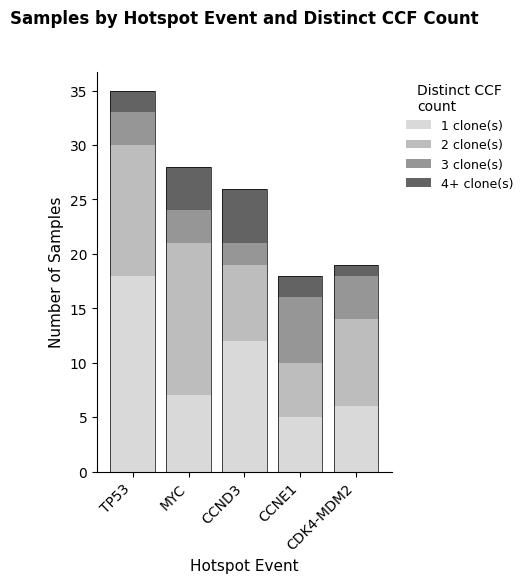

In [109]:
ccf_counts = ["1", "2", "3", "4+"]
gray_shades = sns.color_palette("tab20c")[16:20][::-1]
bin_palette = dict(zip(ccf_counts, gray_shades))

fig, ax = plt.subplots(figsize=(5, 6))
bottom = np.zeros(len(df_summary))
for ccf_count in ccf_counts:
    vals = df_summary[ccf_count].values.astype(float)
    ax.bar(df_summary.index, vals, bottom=bottom, color=bin_palette[ccf_count],
           edgecolor="none", label=f"{ccf_count} clone(s)")
    bottom += vals

totals = df_summary[ccf_counts].sum(axis=1)
ax.bar(df_summary.index, totals, facecolor="none", edgecolor="black", linewidth=0.5)

ax.set_xlabel("Hotspot Event", fontsize=11)
ax.set_ylabel("Number of Samples", fontsize=11)
ax.set_title("Samples by Hotspot Event and Distinct CCF Count", fontweight="bold", fontsize=12, y=1.1)
ax.legend(title="Distinct CCF\ncount", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)
ax.spines[["right", "top"]].set_visible(False)
ax.set_xticks(range(len(df_summary.index)))
ax.set_xticklabels(df_summary.index, rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../../Images/Figures/Subclonality_distribution_in_hotspots_stacked_barplot.svg", format="svg", bbox_inches="tight")
plt.savefig("../../Images/Figures/Subclonality_distribution_in_hotspots_stacked_barplot.pdf", format="pdf", bbox_inches="tight")
plt.show()